<a href="https://colab.research.google.com/github/innocentdevil11/AksharVaani/blob/main/Stroke_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [ ]:
def generate_sample(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    mask = np.zeros((size, size), dtype=np.uint8)

    # ----- CURVE -----
    curve_type = random.choice(["parabola", "sine", "line"])
    x = np.linspace(-1, 1, size)

    if curve_type == "parabola":
        y = x**2
    elif curve_type == "sine":
        y = np.sin(3*x)
    else:
        y = 0.5*x

    x += np.random.uniform(-0.3, 0.3)
    y += np.random.uniform(-0.3, 0.3)

    x_pix = ((x + 1)/2 * (size-1)).astype(int)
    y_pix = ((y - y.min())/(y.max()-y.min()+1e-8) * (size-1)).astype(int)

    for i in range(size):
        if 0 <= x_pix[i] < size and 0 <= y_pix[i] < size:
            cv2.circle(img, (x_pix[i], y_pix[i]), 1, 255, -1)
            cv2.circle(mask, (x_pix[i], y_pix[i]), 1, 1, -1)

    # ----- AXES -----
    if random.random() > 0.5:
        x0 = random.randint(30, size-30)
        cv2.line(img, (x0, 0), (x0, size), 255, 2)
        cv2.line(mask, (x0, 0), (x0, size), 2, 2)

    if random.random() > 0.5:
        y0 = random.randint(30, size-30)
        cv2.line(img, (0, y0), (size, y0), 255, 2)
        cv2.line(mask, (0, y0), (size, y0), 3, 2)

    # ----- TEXT -----
    texts = ["x", "y", "(0,0)", "(1,1)"]
    for _ in range(random.randint(3, 10)):
        text = random.choice(texts)
        x_pos = random.randint(0, size-50)
        y_pos = random.randint(0, size-10)

        cv2.putText(img, text, (x_pos, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 1)

        cv2.putText(mask, text, (x_pos, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, 4, 1)

    return img, mask

In [ ]:
class SyntheticDataset(Dataset):
    def __init__(self, n=1000):
        self.data = [generate_sample() for _ in range(n)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, mask = self.data[idx]

        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [ ]:
dataset = SyntheticDataset(1000)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.dec = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(16, 5, 1)  # 5 classes (0–4)
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.pool(x)
        x = self.dec(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleUNet().to(device)

weights = torch.tensor([0.1, 2.0, 1.5, 1.5, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(20):
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: {total_loss/len(loader):.4f}")

Epoch 0: 0.5849
Epoch 1: 0.1071
Epoch 2: 0.0779
Epoch 3: 0.0693
Epoch 4: 0.0651
Epoch 5: 0.0627
Epoch 6: 0.0611
Epoch 7: 0.0600
Epoch 8: 0.0590
Epoch 9: 0.0584
Epoch 10: 0.0578
Epoch 11: 0.0574
Epoch 12: 0.0571
Epoch 13: 0.0568
Epoch 14: 0.0566
Epoch 15: 0.0561
Epoch 16: 0.0560
Epoch 17: 0.0560
Epoch 18: 0.0557
Epoch 19: 0.0553


In [ ]:
from google.colab import files
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0])
orig = img.copy()

Saving Screenshot 2026-04-11 105638.png to Screenshot 2026-04-11 105638 (3).png


In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

binary = cv2.resize(binary, (256,256))
binary = 255 - binary  # IMPORTANT

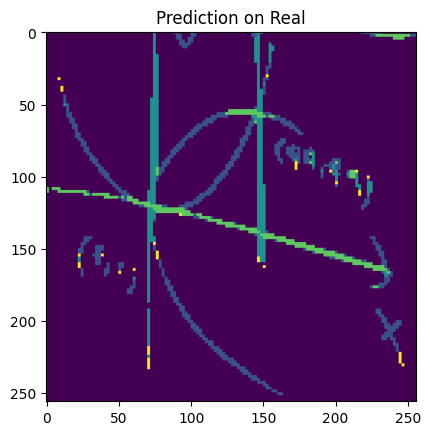

In [ ]:
inp = binary / 255.0
inp = np.expand_dims(inp, axis=(0,1))

inp = torch.tensor(inp, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = torch.argmax(model(inp), dim=1).squeeze().cpu().numpy()

plt.imshow(pred)
plt.title("Prediction on Real")
plt.show()

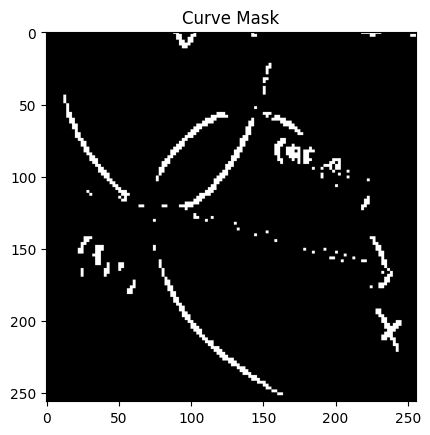

In [ ]:
curve_mask = (pred == 1).astype(np.uint8) * 255

plt.imshow(curve_mask, cmap='gray')
plt.title("Curve Mask")
plt.show()

In [ ]:
points = np.column_stack(np.where(curve_mask > 0))

x = points[:,1]
y = points[:,0]

In [ ]:
x_norm = (x - x.min()) / (x.max() - x.min() + 1e-8)
y_norm = (y - y.min()) / (y.max() - y.min() + 1e-8)

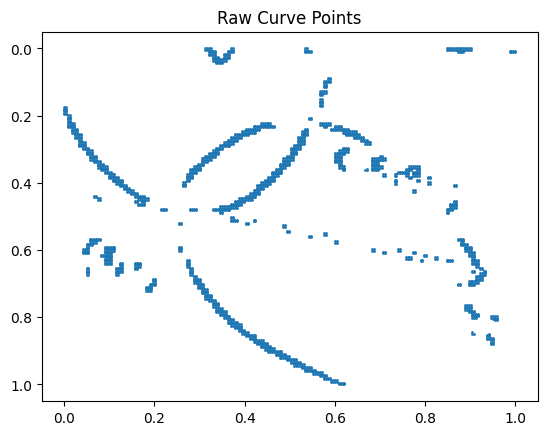

In [ ]:
plt.scatter(x_norm, y_norm, s=1)
plt.gca().invert_yaxis()
plt.title("Raw Curve Points")
plt.show()

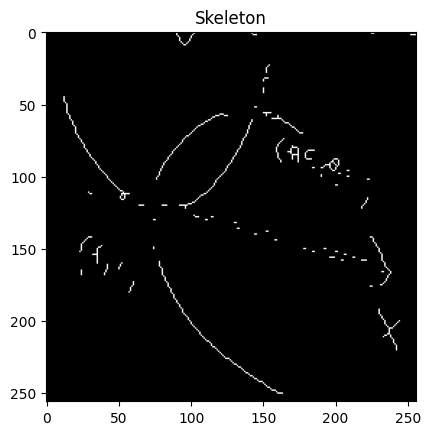

In [ ]:
from skimage.morphology import skeletonize

skel = skeletonize(curve_mask // 255).astype(np.uint8) * 255

plt.imshow(skel, cmap='gray')
plt.title("Skeleton")
plt.show()

In [ ]:
pts = np.column_stack(np.where(skel > 0))

In [ ]:
from scipy.spatial import KDTree
tree = KDTree(pts)
neighbors = tree.query_ball_tree(tree, r=2)

In [ ]:
endpoints = [i for i, n in enumerate(neighbors) if len(n) <= 2]

In [ ]:
from collections import deque

def bfs(start):
    visited = set()
    queue = deque([(start, [start])])
    longest = []

    while queue:
        node, path = queue.popleft()

        if len(path) > len(longest):
            longest = path

        for n in neighbors[node]:
            if n not in path:
                queue.append((n, path + [n]))

    return longest

In [ ]:
best_path = []

for ep in endpoints:
    path = bfs(ep)
    if len(path) > len(best_path):
        best_path = path

curve_pts = pts[best_path]

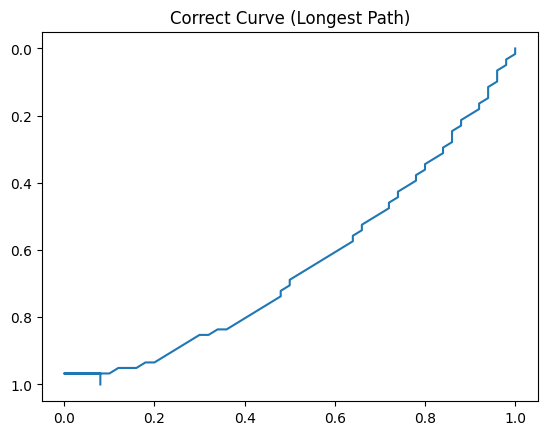

In [ ]:
x = curve_pts[:,1]
y = curve_pts[:,0]

x = (x - x.min()) / (x.max() - x.min() + 1e-8)
y = (y - y.min()) / (y.max() - y.min() + 1e-8)

plt.plot(x, y)
plt.gca().invert_yaxis()
plt.title("Correct Curve (Longest Path)")
plt.show()